# Classification Models Comparison using Iris Dataset
## Objective
The objective of this project is to compare four supervised machine learning classification algorithms using the Iris Dataset.
Algorithms used:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors (KNN)

The models are evaluated using:
- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- Cross Validation

The best-performing model is identified based on evaluation metrics.

# Introduction to Classification

Classification is a Supervised Machine Learning technique used to predict categorical outputs.

Examples:

- Spam / Not Spam
- Disease / No Disease
- Survived / Not Survived
- Flower Species Prediction
In this project, the model predicts the species of an Iris flower based on flower measurements.

# Import Libraries

The following libraries are required:

- Pandas → Data manipulation
- NumPy → Numerical operations
- Matplotlib & Seaborn → Visualization
- Scikit-Learn → Machine Learning algorithms and evaluation metrics

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Load Iris Dataset

The Iris dataset is one of the most popular datasets in Machine Learning.

It contains three flower species:

1. Iris Setosa
2. Iris Versicolor
3. Iris Virginica

Features:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

In [3]:
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df["Species"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# Dataset Exploration

Before training the model, it is important to understand the dataset structure and statistics.

In [4]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape:
(150, 5)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None

Statistical Summary:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350

# Train-Test Split

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

Training data teaches the model.

Testing data evaluates model performance on unseen data.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 120
Testing Samples: 30


# Logistic Regression

Logistic Regression is a classification algorithm that predicts categorical outputs.

In [6]:
log_model = LogisticRegression(max_iter=200)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

In [18]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": log_pred
})

comparison.head(10)

,Actual,Predicted
0,1,1
1,0,0
2,2,2
3,1,1
4,1,1
5,0,0
6,1,1
7,2,2
8,1,1
9,1,1


# Decision Tree

Decision Tree works like a flowchart where decisions are made based on feature values.

In [7]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [25]:
new_flower = [[5.8, 2.5, 4.4, 4.2]]

prediction = dt_model.predict(new_flower)

print(iris.target_names[prediction[0]])

virginica


# Random Forest

Random Forest combines multiple decision trees to improve accuracy and reduce overfitting.

In [8]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# K-Nearest Neighbors (KNN)

KNN classifies a new data point based on the majority class of its nearest neighbors.

In [9]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

# Evaluation Metrics

The following metrics are used:

- Accuracy
Accuracy measures the overall correctness of the model.
Higher accuracy indicates better performance.

- Precision

Precision measures how many of the predicted positive observations were actually correct.
Higher precision means fewer false positive predictions.

- Recall

Recall measures how many actual positive observations were correctly identified.
Higher recall means the model successfully identifies more actual positive cases.

- F1 Score

F1 Score combines Precision and Recall into a single metric.
The F1 Score is useful when both Precision and Recall are important.

A higher F1 Score indicates a better balance between Precision and Recall.

These metrics help compare model performance.

In [11]:
models = {
    "Logistic Regression": log_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "KNN": knn_pred
}

results = []

for name, pred in models.items():

    accuracy = accuracy_score(y_test, pred)

    precision = precision_score(
        y_test,
        pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        pred,
        average="weighted"
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0
3,KNN,1.0,1.0,1.0,1.0


# Confusion Matrix Visualization

A confusion matrix shows correct and incorrect classifications made by the model.

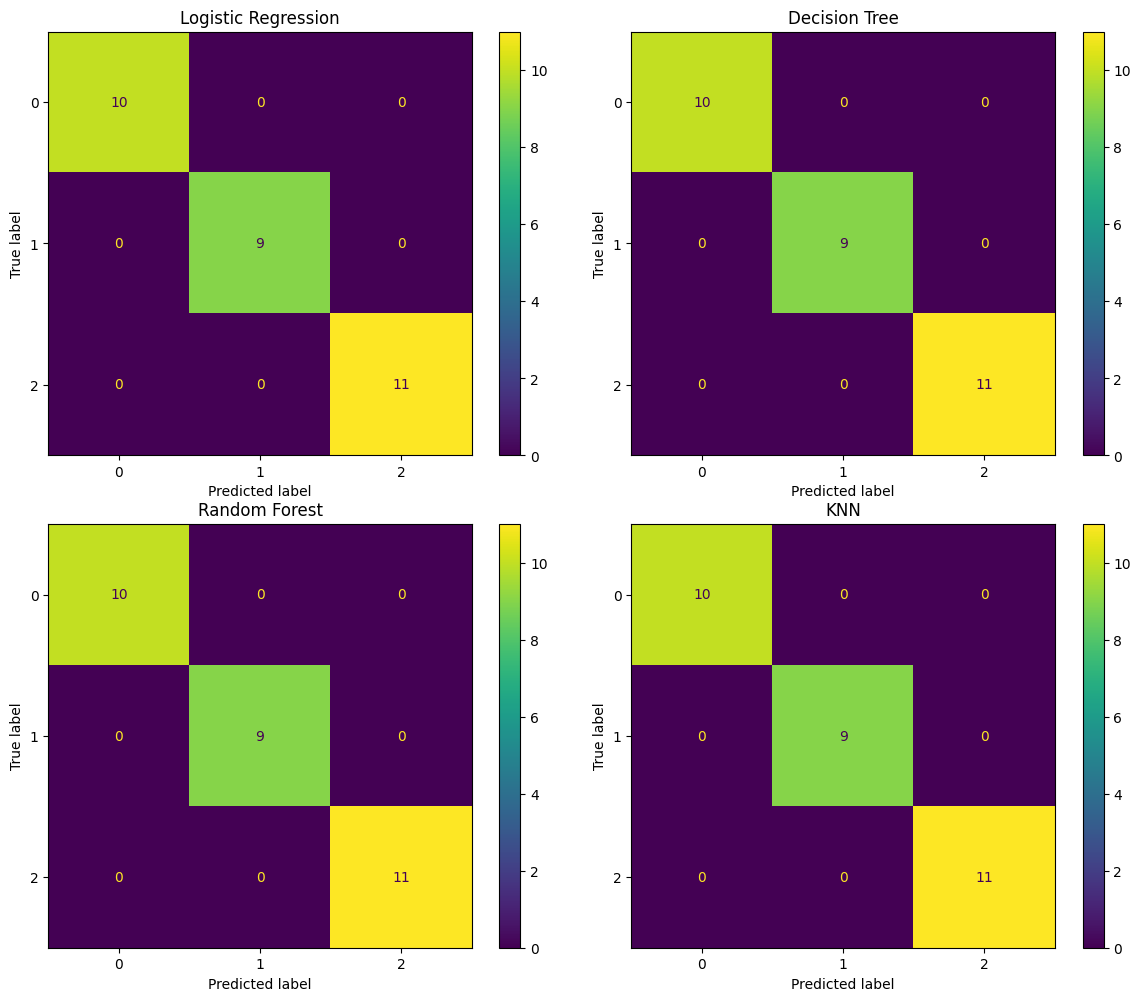

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

model_list = [
    ("Logistic Regression", log_pred),
    ("Decision Tree", dt_pred),
    ("Random Forest", rf_pred),
    ("KNN", knn_pred)
]

for ax, (name, pred) in zip(axes.ravel(), model_list):

    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot(ax=ax)

    ax.set_title(name)

plt.tight_layout()
plt.show()

# Cross Validation

Cross Validation evaluates the model multiple times and returns an average score.

This reduces bias caused by a single train-test split.

In [16]:
models_cv = {
    "Logistic Regression":
        LogisticRegression(max_iter=200),

    "Decision Tree":
        DecisionTreeClassifier(),

    "Random Forest":
        RandomForestClassifier(),

    "KNN":
        KNeighborsClassifier()
}

cv_results = []

for name, model in models_cv.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5
    )

    cv_results.append([
        name,
        scores.mean()
    ])

cv_df = pd.DataFrame(
    cv_results,
    columns=[
        "Model",
        "Cross Validation Accuracy"
    ]
)

cv_df

,Model,Cross Validation Accuracy
0,Logistic Regression,0.973333
1,Decision Tree,0.966667
2,Random Forest,0.960000
3,KNN,0.973333


# Comparison Table

The following table compares all models based on evaluation metrics.

In [17]:
comparison_df = results_df.merge(
    cv_df,
    on="Model"
)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,Cross Validation Accuracy
0,Logistic Regression,1.0,1.0,1.0,1.0,0.973333
1,Decision Tree,1.0,1.0,1.0,1.0,0.966667
2,Random Forest,1.0,1.0,1.0,1.0,0.960000
3,KNN,1.0,1.0,1.0,1.0,0.973333
